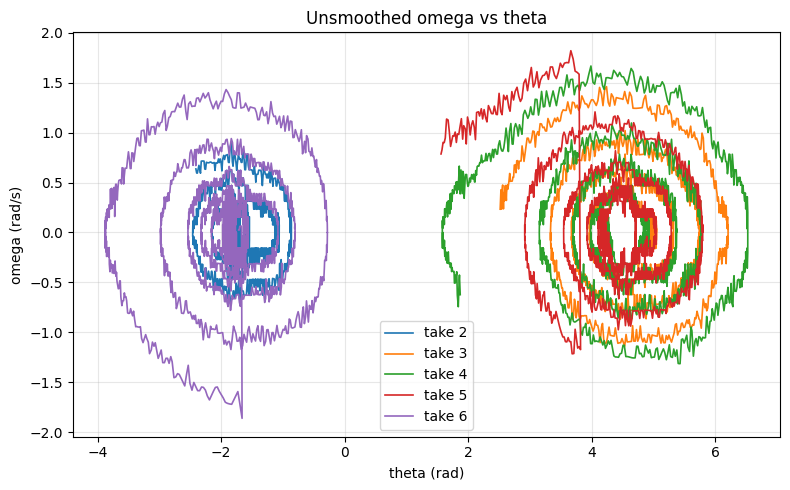

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


fps = 50
dt = 1 / fps

# ------------------------------
# List your files explicitly
# ------------------------------
file_list = [
    "tracking_output_2.csv",
    "tracking_output_3.csv",
    "tracking_output_4.csv",
    "tracking_output_5.csv",
    "tracking_output_6.csv",
]

plt.figure(figsize=(8, 5))

for fn in file_list:
    df = pd.read_csv(fn)

    theta = df["theta_rad"].to_numpy()
    frame = df["frame"].to_numpy()
    t = frame * dt

    valid = np.isfinite(theta) & np.isfinite(t)
    thv = theta[valid]
    tv = t[valid]

    theta_cont = np.unwrap(thv)
    omega = np.gradient(theta_cont, tv)       # unsmoothed omega

    run_name = fn.replace("tracking_output_", "take ").replace(".csv", "")
    plt.plot(theta_cont, omega, lw=1.2, label=run_name)

plt.xlabel("theta (rad)")
plt.ylabel("omega (rad/s)")
plt.title("Unsmoothed omega vs theta")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

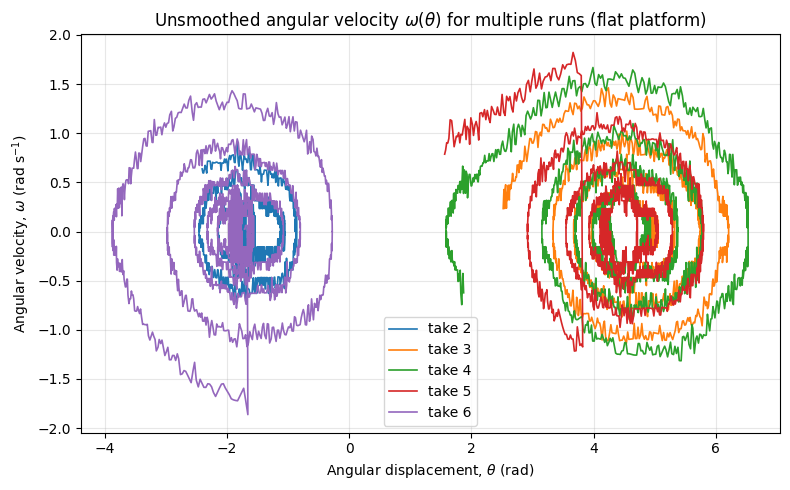

In [ ]:
plt.figure(figsize=(8, 5))

for fn in file_list:
    df = pd.read_csv(fn)

    theta = df["theta_rad"].to_numpy()
    frame = df["frame"].to_numpy()
    t = frame * dt

    valid = np.isfinite(theta) & np.isfinite(t)
    thv = theta[valid]
    tv = t[valid]

    theta_cont = np.unwrap(thv)
    omega = np.gradient(theta_cont, tv)  # unsmoothed angular velocity

    run_name = fn.replace("tracking_output_", "take ").replace(".csv", "")
    plt.plot(theta_cont, omega, lw=1.2, label=run_name)

plt.xlabel(r'Angular displacement, $\theta$ (rad)')
plt.ylabel(r'Angular velocity, $\omega$ (rad s$^{-1}$)')
plt.title(r'Unsmoothed angular velocity $\omega(\theta)$ for multiple runs (flat platform)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('unsmoothed_omega_vs_theta_all_runs.png',
            dpi=400, bbox_inches='tight')
plt.show()

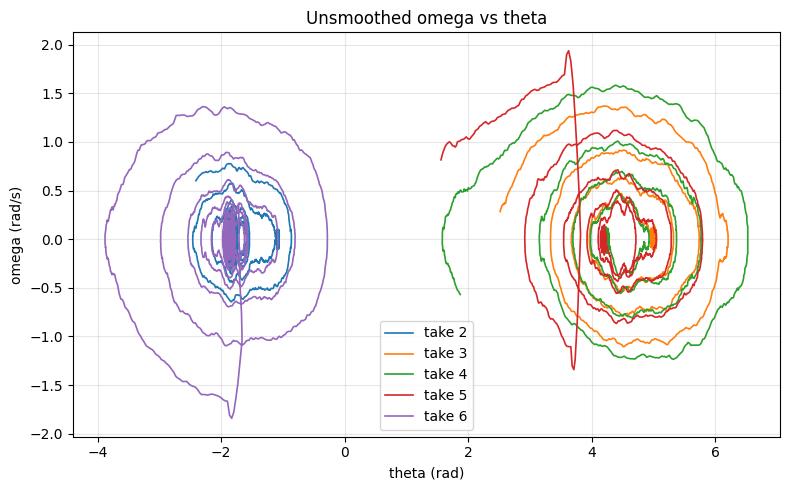

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

fps = 50
dt = 1 / fps

# ------------------------------
# List your files explicitly
# ------------------------------
file_list = [
    "tracking_output_2.csv",
    "tracking_output_3.csv",
    "tracking_output_4.csv",
    "tracking_output_5.csv",
    "tracking_output_6.csv",
]

plt.figure(figsize=(8, 5))

for fn in file_list:
    df = pd.read_csv(fn)

    theta = df["theta_rad"].to_numpy()
    frame = df["frame"].to_numpy()
    t = frame * dt

    valid = np.isfinite(theta) & np.isfinite(t)
    thv = theta[valid]
    tv = t[valid]

    theta_cont = np.unwrap(thv)
    omega = np.gradient(theta_cont, tv)       # unsmoothed omega
    omega_s = savgol_filter(omega, window_length=15, polyorder=2)

    run_name = fn.replace("tracking_output_", "take ").replace(".csv", "")
    plt.plot(theta_cont, omega_s, lw=1.2, label=run_name)

plt.xlabel("theta (rad)")
plt.ylabel("omega (rad/s)")
plt.title("Unsmoothed omega vs theta")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

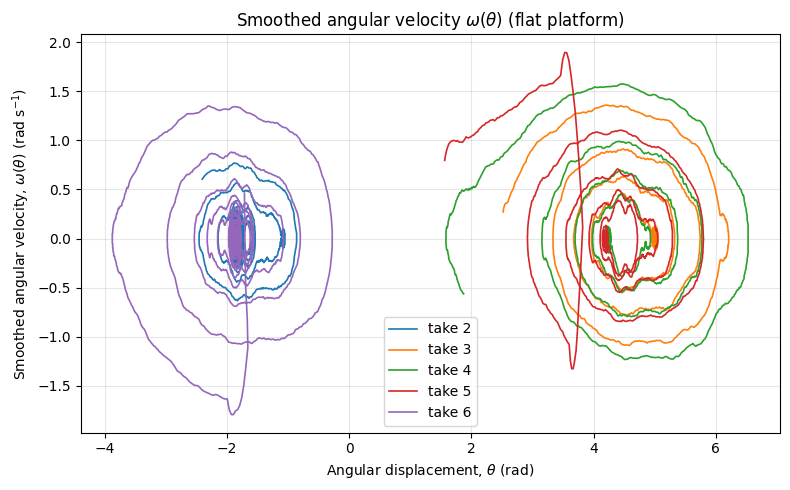

In [ ]:
plt.figure(figsize=(8, 5))

for fn in file_list:
    df = pd.read_csv(fn)

    theta = df["theta_rad"].to_numpy()
    frame = df["frame"].to_numpy()
    t = frame * dt

    valid = np.isfinite(theta) & np.isfinite(t)
    thv = theta[valid]
    tv = t[valid]

    theta_cont = np.unwrap(thv)
    omega = np.gradient(theta_cont, tv)       # unsmoothed omega
    omega_s = savgol_filter(omega, window_length=21, polyorder=3)

    run_name = fn.replace("tracking_output_", "take ").replace(".csv", "")
    plt.plot(theta_cont, omega_s, lw=1.2, label=run_name)

plt.xlabel(r'Angular displacement, $\theta$ (rad)')
plt.ylabel(r'Smoothed angular velocity, $\omega(\theta)$ (rad s$^{-1}$)')
plt.title(r'Smoothed angular velocity $\omega(\theta)$ (flat platform)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('smoothed_omega_vs_theta_all_runs.png',
            dpi=400, bbox_inches='tight')
plt.show()

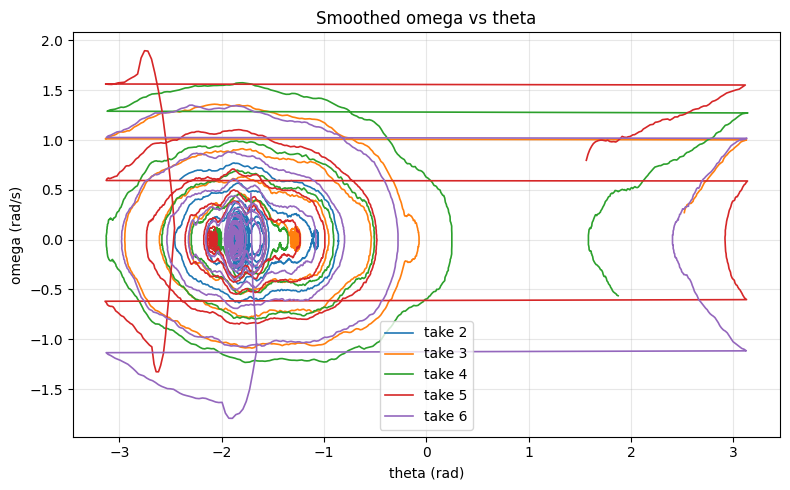

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter


fps = 50
dt = 1 / fps

# ------------------------------
# List your files explicitly
# ------------------------------

file_list = [
    "tracking_output_2.csv",
    "tracking_output_3.csv",
    "tracking_output_4.csv",
    "tracking_output_5.csv",
    "tracking_output_6.csv",
]

plt.figure(figsize=(8, 5))

for fn in file_list:
    df = pd.read_csv(fn)

    theta = df["theta_rad"].to_numpy()
    frame = df["frame"].to_numpy()
    t = frame * dt

    valid = np.isfinite(theta) & np.isfinite(t)
    thv = theta[valid]
    tv = t[valid]

    theta_cont = np.unwrap(thv)
    omega = np.gradient(theta_cont, tv)       # unsmoothed omega
    omega_s = savgol_filter(omega, window_length=21, polyorder=3)  #smoothed omega

    run_name = fn.replace("tracking_output_", "take ").replace(".csv", "")
    plt.plot(thv, omega_s, lw=1.2, label=run_name)

plt.xlabel("theta (rad)")
plt.ylabel("omega (rad/s)")
plt.title("Smoothed omega vs theta")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


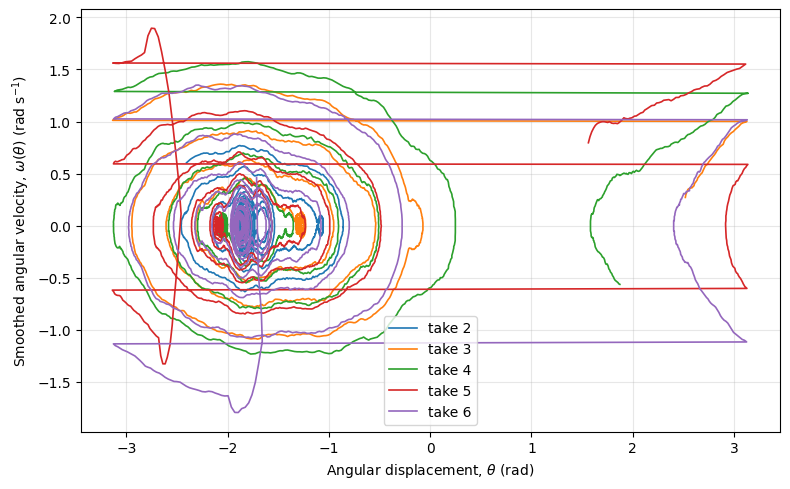

In [ ]:
from scipy.signal import savgol_filter

plt.figure(figsize=(8, 5))

for fn in file_list:
    df = pd.read_csv(fn)

    theta = df["theta_rad"].to_numpy()
    frame = df["frame"].to_numpy()
    t = frame * dt

    valid = np.isfinite(theta) & np.isfinite(t)
    thv = theta[valid]
    tv = t[valid]

    theta_cont = np.unwrap(thv)
    omega = np.gradient(theta_cont, tv)  # unsmoothed angular velocity

    # Savitzky–Golay smoothing (window length must be odd)
    omega_s = savgol_filter(omega, window_length=21, polyorder=3)
    run_name = fn.replace("tracking_output_", "take ").replace(".csv", "")
    plt.plot(thv, omega_s, lw=1.2, label=run_name)

plt.xlabel(r'Angular displacement, $\theta$ (rad)')
plt.ylabel(r'Smoothed angular velocity, $\omega(\theta)$ (rad s$^{-1}$)')
#plt.title(r'Smoothed angular velocity $\omega(\theta)$ (flat platform)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('smoothed_omega_vs_theta_all_runs.png',
            dpi=400, bbox_inches='tight')
plt.show()

## Different unfolding

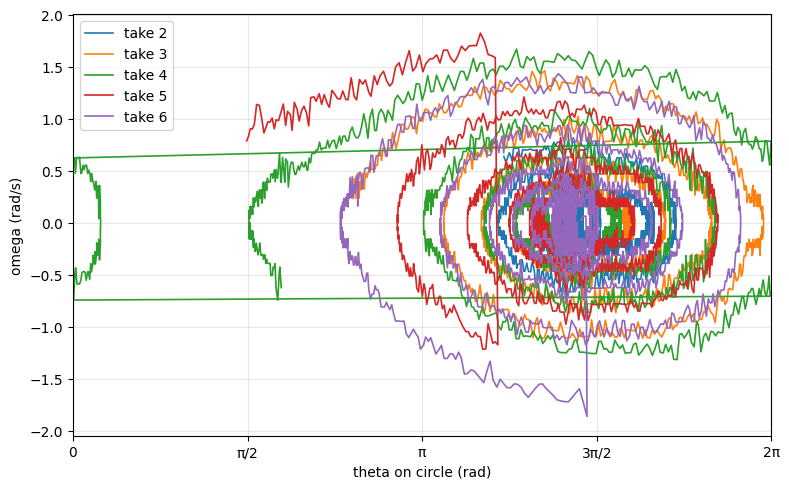

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


fps = 50
dt = 1 / fps

# ------------------------------
# List your files explicitly
# ------------------------------
file_list = [
    "tracking_output_2.csv",
    "tracking_output_3.csv",
    "tracking_output_4.csv",
    "tracking_output_5.csv",
    "tracking_output_6.csv",
]

plt.figure(figsize=(8, 5))

for fn in file_list:
    df = pd.read_csv(fn)

    theta = df["theta_rad"].to_numpy()
    frame = df["frame"].to_numpy()
    t = frame * dt

    valid = np.isfinite(theta) & np.isfinite(t)
    thv = theta[valid]
    tv = t[valid]

    # 1) unwrap for correct differentiation
    theta_cont = np.unwrap(thv)

    # 2) omega from continuous theta
    omega = np.gradient(theta_cont, tv)

    # 3) fold angle back to one physical circle: 0 to 2pi
    theta_circle = np.mod(theta_cont, 2*np.pi)

    run_name = fn.replace("tracking_output_", "take ").replace(".csv", "")
    plt.plot(theta_circle, omega, lw=1.2, label=run_name)

plt.xlabel("theta on circle (rad)")
plt.ylabel("omega (rad/s)")
plt.xlim(0, 2*np.pi)
plt.xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    ["0", "π/2", "π", "3π/2", "2π"]
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

this foldes everything into 0-2pi, whih is wrong since different runs settles at different spots on the circle, so the spiral don't overlap

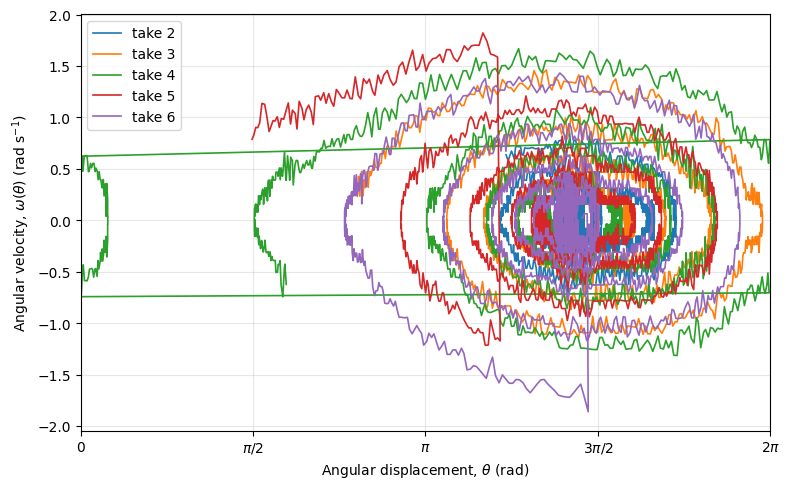

In [ ]:
plt.figure(figsize=(8, 5))

for fn in file_list:
    df = pd.read_csv(fn)

    theta = df["theta_rad"].to_numpy()
    frame = df["frame"].to_numpy()
    t = frame * dt

    valid = np.isfinite(theta) & np.isfinite(t)
    thv = theta[valid]
    tv = t[valid]

    # 1) unwrap for correct differentiation
    theta_cont = np.unwrap(thv)

    # 2) omega from continuous theta
    omega = np.gradient(theta_cont, tv)

    # 3) fold angle back to one physical circle: 0 to 2π
    theta_circle = np.mod(theta_cont, 2 * np.pi)

    run_name = fn.replace("tracking_output_", "take ").replace(".csv", "")
    plt.plot(theta_circle, omega, lw=1.2, label=run_name)

plt.xlabel(r'Angular displacement, $\theta$ (rad)')
plt.ylabel(r'Angular velocity, $\omega(\theta)$ (rad s$^{-1}$)')
#plt.title(r'Angular velocity $\omega(\theta)$ folded onto one rotation (flat platform)')
plt.xlim(0, 2 * np.pi)
plt.xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('omega_vs_theta_folded_0_to_2pi.png',
            dpi=400, bbox_inches='tight')
plt.show()